# Power of d Choices: array version

The same model as `power-of-d-choices.ipynb`, tracking only the number of shoppers in each line with a numpy array
instead of `Line` and `Shopper` objects. It is a small run (500 steps, a lighter load) that is easy to inspect,
and a check that the two implementations agree.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))  # project root, so checkout_queues imports without installing
from checkout_queues.sim_worker import random_inputs, simulate_line_lengths, simulate_store

N = 500      # time steps
nl = 7       # lines
p_a = 0.31   # shopper arrival per step
p_c = 0.06   # checkout (per line, per step)

arrivals, line_orders, checkouts = random_inputs(N, nl, p_a, p_c, rng=7)

Each step, a shopper (if one arrives) inspects the first `d` lines of that step's random order, `line_orders[t]`,
and joins the shortest; then every non-empty line flagged in `checkouts[t]` loses its front shopper.

In [2]:
print("first 5 line orders:\n", line_orders[:5])
lengths = {d: simulate_line_lengths(d, arrivals, line_orders, checkouts) for d in range(1, nl + 1)}

d = 2
print(f"\nd = {d}, first 20 steps (line lengths, then shoppers in the store):")
for t in range(20):
    print(f"{t:3d}  arrival={int(arrivals[t])}  {lengths[d][t]}  {lengths[d][t].sum()}")

first 5 line orders:
 [[1 6 5 2 3 0 4]
 [2 0 1 4 3 6 5]
 [6 3 4 2 0 5 1]
 [4 0 3 6 2 5 1]
 [4 6 2 3 1 5 0]]

d = 2, first 20 steps (line lengths, then shoppers in the store):
  0  arrival=0  [0 0 0 0 0 0 0]  0
  1  arrival=0  [0 0 0 0 0 0 0]  0
  2  arrival=0  [0 0 0 0 0 0 0]  0
  3  arrival=1  [0 0 0 0 1 0 0]  1
  4  arrival=1  [0 0 0 0 1 0 1]  2
  5  arrival=0  [0 0 0 0 1 0 1]  2
  6  arrival=1  [0 0 1 0 1 0 1]  3
  7  arrival=0  [0 0 1 0 1 0 1]  3
  8  arrival=0  [0 0 1 0 1 0 1]  3
  9  arrival=0  [0 0 1 0 1 0 1]  3
 10  arrival=1  [0 0 1 0 1 1 1]  4
 11  arrival=1  [0 0 1 0 1 2 1]  5
 12  arrival=1  [0 1 1 0 1 2 1]  6
 13  arrival=0  [0 1 1 0 1 2 1]  6
 14  arrival=0  [0 1 1 0 1 2 1]  6
 15  arrival=0  [0 1 1 0 1 2 1]  6
 16  arrival=0  [0 1 1 0 1 2 1]  6
 17  arrival=0  [0 1 1 0 1 2 1]  6
 18  arrival=0  [0 1 1 0 1 2 1]  6
 19  arrival=0  [0 1 1 0 1 2 1]  6


The array version matches the object model step for step:

In [3]:
for d in lengths:
    np.testing.assert_allclose(simulate_store(d, arrivals, line_orders, checkouts)["avg_shoppers"],
                               lengths[d].mean(axis=1))
print("array and object versions agree for every d")

array and object versions agree for every d


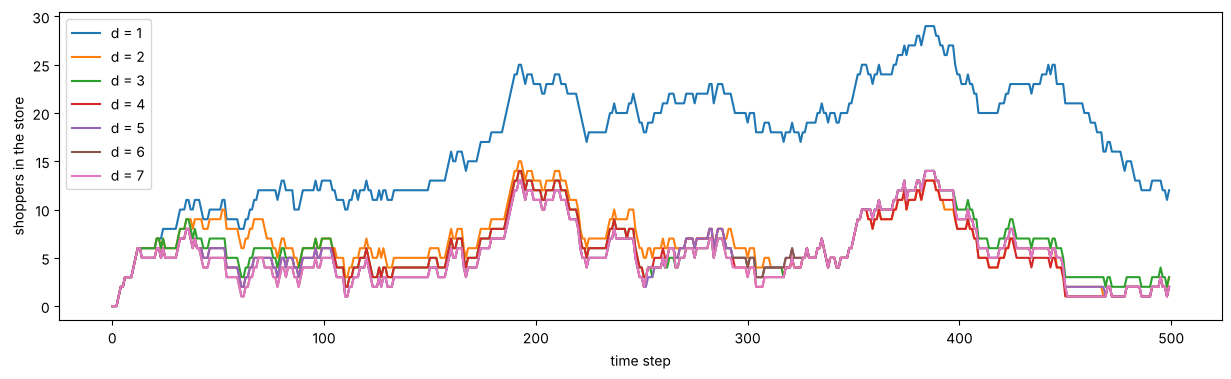

In [4]:
shoppers_in_store = pd.DataFrame({f"d = {d}": l.sum(axis=1) for d, l in lengths.items()})
ax = shoppers_in_store.plot(figsize=(15, 4))
ax.set_xlabel("time step")
ax.set_ylabel("shoppers in the store")
plt.show()